# Laughlin & Halperin Monte Carlo
Real‑space density profiles of fractional quantum Hall states via Metropolis sampling of $|\psi|^2$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import Laughlin
from time import time

## 1. Single‑species Laughlin states  ($m = 1, 3, 5$)

m=1: 2.0s
m=3: 3.5s
m=5: 2.3s


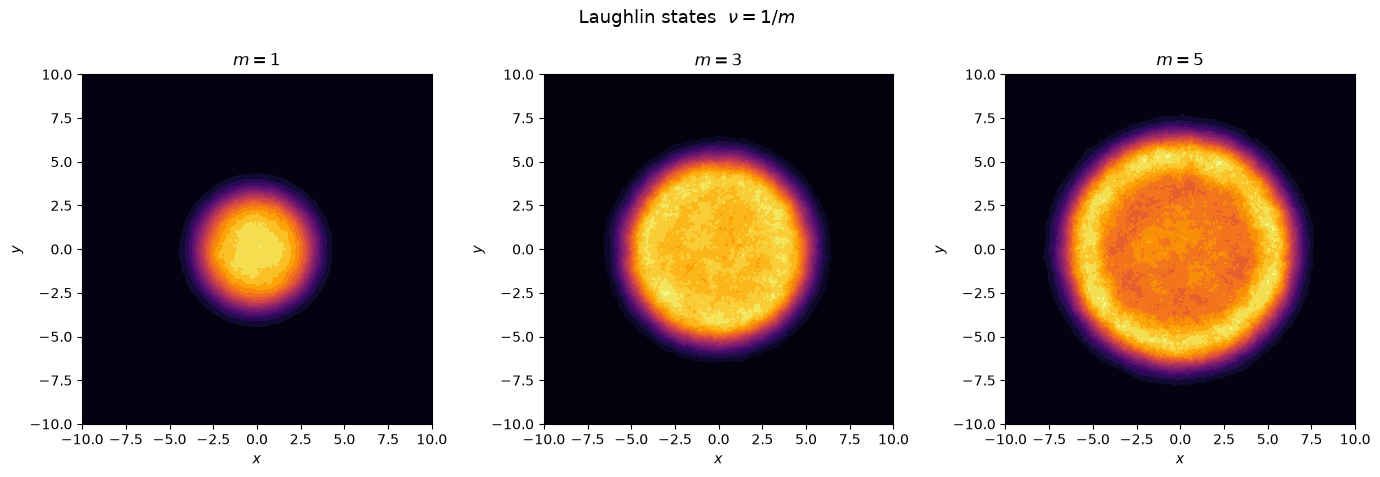

In [3]:
BDR  = 20.0
RES  = 0.1
STEPS = 2000000
N_PART = 10

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for m_val, ax in zip([1, 3, 5], axes):
    t0 = time()
    int_mat = np.array([[float(m_val)]], dtype=np.float32)
    sim = Laughlin.Laughlin(int_mat,
                            np.array([N_PART], dtype=np.int32),
                            1, BDR, RES)
    sim.run(STEPS)
    hist = sim.get_histogram()
    bins = sim.get_bins()

    density = hist[0].astype(np.float64)
    density /= density.sum() * RES * RES

    xs = np.linspace(-BDR, BDR, bins)
    X, Y = np.meshgrid(xs, xs)

    ax.contourf(X, Y, density, levels=20, origin='lower', cmap='inferno')
    ax.set_aspect('equal')
    ax.set_title(f'$m = {m_val}$')
    ax.set_xlim(-10, 10); ax.set_ylim(-10, 10)
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
    print(f'm={m_val}: {time() - t0:.1f}s')

plt.suptitle('Laughlin states  $\\nu = 1/m$', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 2. Halperin 331  (two interpenetrating species)

Species A:  mean radius = 5.20
Species B:  mean radius = 5.19
Interpenetration ratio: 0.9985  (1 = fully mixed)
Time: 21.8s


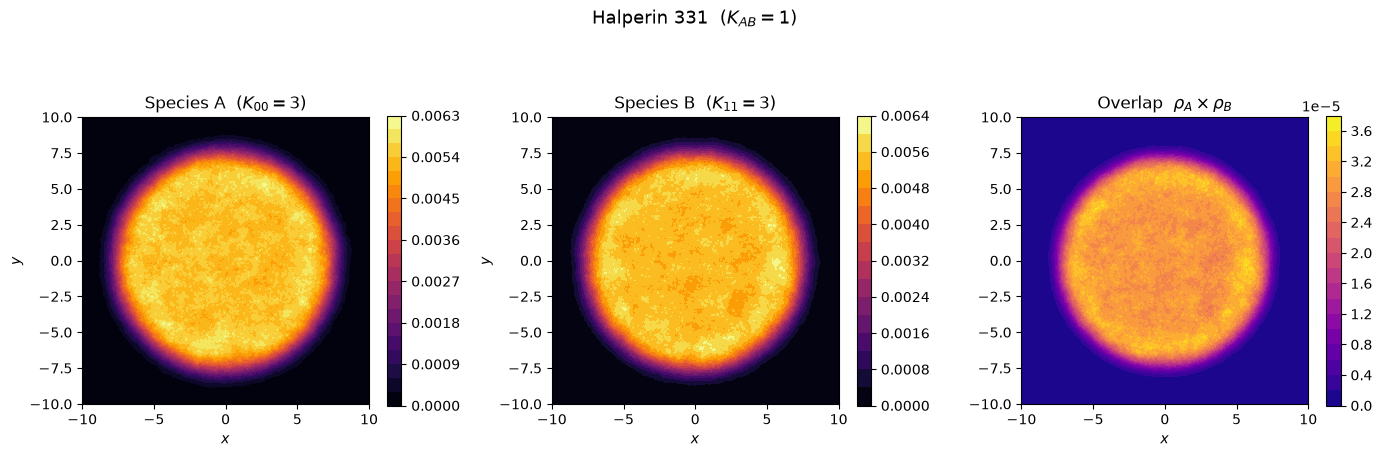

In [4]:
# K = [[3, 1], [1, 3]]
int_mat = np.array([[3.0, 1.0],
                     [1.0, 3.0]], dtype=np.float32)
n_part  = np.array([15, 15], dtype=np.int32)

t0 = time()
sim = Laughlin.Laughlin(int_mat, n_part, 2, BDR, RES)
sim.run(STEPS)
hist = sim.get_histogram()
bins = sim.get_bins()

density = hist.astype(np.float64)
for t in range(2):
    density[t] /= density[t].sum() * RES * RES

xs = np.linspace(-BDR, BDR, bins)
X, Y = np.meshgrid(xs, xs)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for t, label, ax in zip([0, 1], ['Species A', 'Species B'], axes[:2]):
    im = ax.contourf(X, Y, density[t], levels=20, origin='lower', cmap='inferno')
    ax.set_aspect('equal')
    ax.set_title(f'{label}  $(K_{{{t}{t}}}=3)$')
    ax.set_xlim(-10, 10); ax.set_ylim(-10, 10)
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
    plt.colorbar(im, ax=ax, shrink=0.75)

# overlap
overlap = density[0] * density[1]
im = axes[2].contourf(X, Y, overlap, levels=20, origin='lower', cmap='plasma')
axes[2].set_aspect('equal')
axes[2].set_title('Overlap  $\\rho_A \\times \\rho_B$')
axes[2].set_xlim(-10, 10); axes[2].set_ylim(-10, 10)
axes[2].set_xlabel('$x$')
plt.colorbar(im, ax=axes[2], shrink=0.75)

# quantitative
y_idx, x_idx = np.meshgrid(np.arange(bins), np.arange(bins), indexing='ij')
r = np.sqrt(xs[x_idx]**2 + xs[y_idx]**2)
for t, label in enumerate(['A', 'B']):
    mr = np.average(r.ravel(), weights=density[t].ravel())
    print(f'Species {label}:  mean radius = {mr:.2f}')

ov = np.sum(hist[0].astype(float) * hist[1].astype(float))
s0 = np.sum(hist[0].astype(float)**2)
s1 = np.sum(hist[1].astype(float)**2)
print(f'Interpenetration ratio: {ov / np.sqrt(s0 * s1):.4f}  (1 = fully mixed)')
print(f'Time: {time() - t0:.1f}s')

plt.suptitle('Halperin 331  $(K_{AB}=1)$', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Harper 313
Lets try some other Harper states:

Species A:  mean radius = 7.68
Species B:  mean radius = 3.60
Interpenetration ratio: 0.1608  (1 = fully mixed)
Time: 24.3s


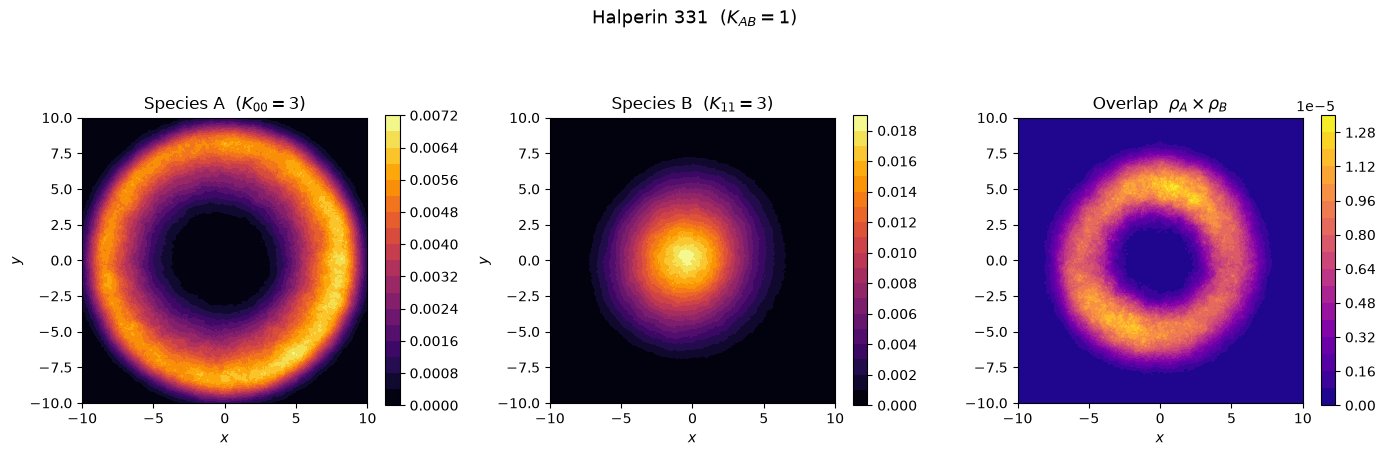

In [ ]:
int_mat = np.array([[3.0, 3.0],
                     [3.0, 1.0]], dtype=np.float32)
n_part  = np.array([15, 15], dtype=np.int32)

t0 = time()
sim = Laughlin.Laughlin(int_mat, n_part, 2, BDR, RES)
sim.run(STEPS)
hist = sim.get_histogram()
bins = sim.get_bins()

density = hist.astype(np.float64)
for t in range(2):
    density[t] /= density[t].sum() * RES * RES

xs = np.linspace(-BDR, BDR, bins)
X, Y = np.meshgrid(xs, xs)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for t, label, ax in zip([0, 1], ['Species A', 'Species B'], axes[:2]):
    im = ax.contourf(X, Y, density[t], levels=20, origin='lower', cmap='inferno')
    ax.set_aspect('equal')
    ax.set_title(f'{label}  $(K_{{{t}{t}}}={int_mat[t,t]})$')
    ax.set_xlim(-10, 10); ax.set_ylim(-10, 10)
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
    plt.colorbar(im, ax=ax, shrink=0.75)

# overlap
overlap = density[0] * density[1]
im = axes[2].contourf(X, Y, overlap, levels=20, origin='lower', cmap='plasma')
axes[2].set_aspect('equal')
axes[2].set_title('Overlap  $\\rho_A \\times \\rho_B$')
axes[2].set_xlim(-10, 10); axes[2].set_ylim(-10, 10)
axes[2].set_xlabel('$x$')
plt.colorbar(im, ax=axes[2], shrink=0.75)

# quantitative
y_idx, x_idx = np.meshgrid(np.arange(bins), np.arange(bins), indexing='ij')
r = np.sqrt(xs[x_idx]**2 + xs[y_idx]**2)
for t, label in enumerate(['A', 'B']):
    mr = np.average(r.ravel(), weights=density[t].ravel())
    print(f'Species {label}:  mean radius = {mr:.2f}')

ov = np.sum(hist[0].astype(float) * hist[1].astype(float))
s0 = np.sum(hist[0].astype(float)**2)
s1 = np.sum(hist[1].astype(float)**2)
print(f'Interpenetration ratio: {ov / np.sqrt(s0 * s1):.4f}  (1 = fully mixed)')
print(f'Time: {time() - t0:.1f}s')

plt.suptitle('Halperin 313  $(K_{AB} = 3)$', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Quasiholes
A quasihole at $\eta$ multiplies $\prod_i |z_i - \eta|^{2p}$ to $|\psi|^2$.  

Time: 3.9s


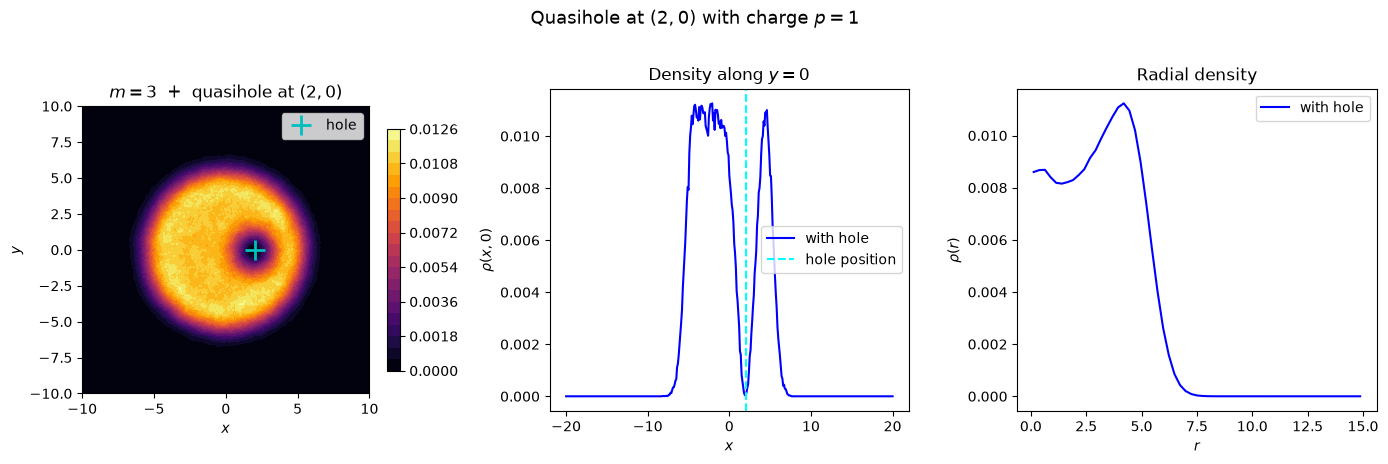

In [5]:
hole_pos = np.array([[2.0, 0.0]], dtype=np.float32)
hole_chg = np.array([1.0], dtype=np.float32)     # p = 1

sim_h = Laughlin.Laughlin(np.array([[3.0]], dtype=np.float32),
                          np.array([10], dtype=np.int32),
                          1, BDR, RES, hole_pos, hole_chg)
t0 = time()
sim_h.run(STEPS)

hist_h = sim_h.get_histogram()
density_h = hist_h[0].astype(np.float64)
density_h /= density_h.sum() * RES * RES

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(14, 4.5))

# 2D density
im = ax0.contourf(X, Y, density_h, levels=20, origin='lower', cmap='inferno')
ax0.plot(2.0, 0.0, 'c+', markersize=15, markeredgewidth=2, label='hole')
ax0.set_aspect('equal')
ax0.set_title('$m=3$  +  quasihole at $(2,0)$')
ax0.set_xlim(-10, 10); ax0.set_ylim(-10, 10)
ax0.set_xlabel('$x$'); ax0.set_ylabel('$y$')
ax0.legend()
plt.colorbar(im, ax=ax0, shrink=0.75)

# density along y=0 (through the hole)
y0_bin = bins // 2
ax1.plot(xs, density_h[y0_bin, :], 'b-', label='with hole')
ax1.axvline(2.0, color='cyan', linestyle='--', label='hole position')
ax1.set_xlabel('$x$'); ax1.set_ylabel('$\\rho(x, 0)$')
ax1.set_title('Density along $y=0$')
ax1.legend()

# radial profile
y_idx, x_idx = np.meshgrid(np.arange(bins), np.arange(bins), indexing='ij')
r = np.sqrt(xs[x_idx]**2 + xs[y_idx]**2)
r_flat = r.ravel()

# bin radial profile
r_bins = np.linspace(0, 15, 60)
r_centers = 0.5 * (r_bins[:-1] + r_bins[1:])
radial, _ = np.histogram(r_flat, bins=r_bins, weights=density_h.ravel())
counts, _ = np.histogram(r_flat, bins=r_bins)
radial = np.where(counts > 0, radial / counts, 0)

ax2.plot(r_centers, radial, 'b-', label='with hole')
ax2.set_xlabel('$r$'); ax2.set_ylabel('$\\rho(r)$')
ax2.set_title('Radial density')
ax2.legend()

print(f'Time: {time() - t0:.1f}s')
plt.suptitle('Quasihole at $(2,0)$ with charge $p=1$', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()